# MNIST 本地数据检查

读取 `data/raw` 下四个 gzip 文件，查看图像尺寸、像素范围与标签分布，并可视化若干样本。

依赖：`numpy`、`matplotlib`（`pip install numpy matplotlib`）。

若数据不在默认路径，请修改下一单元中的 `DATA_DIR`。

In [1]:
import gzip
import struct
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

DATA_DIR = Path("/data1/zdguo/document-parsing/alextools/experiment/MNIST/data/raw")


def load_images(path: Path) -> np.ndarray:
    """MNIST images: magic 2051, then N, rows, cols, then N*rows*cols uint8."""
    with gzip.open(path, "rb") as f:
        magic, n, rows, cols = struct.unpack(">IIII", f.read(16))
        if magic != 2051:
            raise ValueError(f"bad magic {magic}, expected 2051")
        buf = f.read(n * rows * cols)
    return np.frombuffer(buf, dtype=np.uint8).reshape(n, rows, cols)


def load_labels(path: Path) -> np.ndarray:
    """MNIST labels: magic 2049, then N, then N uint8."""
    with gzip.open(path, "rb") as f:
        magic, n = struct.unpack(">II", f.read(8))
        if magic != 2049:
            raise ValueError(f"bad magic {magic}, expected 2049")
        buf = f.read(n)
    return np.frombuffer(buf, dtype=np.uint8)


for name in [
    "train-images-idx3-ubyte.gz",
    "train-labels-idx1-ubyte.gz",
    "t10k-images-idx3-ubyte.gz",
    "t10k-labels-idx1-ubyte.gz",
]:
    p = DATA_DIR / name
    print(f"{'OK' if p.is_file() else 'MISSING':7} {p}")

OK      /data1/zdguo/document-parsing/alextools/experiment/MNIST/data/raw/train-images-idx3-ubyte.gz
OK      /data1/zdguo/document-parsing/alextools/experiment/MNIST/data/raw/train-labels-idx1-ubyte.gz
OK      /data1/zdguo/document-parsing/alextools/experiment/MNIST/data/raw/t10k-images-idx3-ubyte.gz
OK      /data1/zdguo/document-parsing/alextools/experiment/MNIST/data/raw/t10k-labels-idx1-ubyte.gz


In [2]:
train_x = load_images(DATA_DIR / "train-images-idx3-ubyte.gz")
train_y = load_labels(DATA_DIR / "train-labels-idx1-ubyte.gz")
test_x = load_images(DATA_DIR / "t10k-images-idx3-ubyte.gz")
test_y = load_labels(DATA_DIR / "t10k-labels-idx1-ubyte.gz")

print("=== 图像张量 ===")
print("train_x:", train_x.shape, train_x.dtype, "min/max:", train_x.min(), train_x.max())
print("test_x: ", test_x.shape, test_x.dtype, "min/max:", test_x.min(), test_x.max())
_, h, w = train_x.shape
print(f"单张尺寸: 高={h}, 宽={w}（HW 格式，无通道维）")

print("\n=== 标签向量 ===")
print("train_y:", train_y.shape, train_y.dtype)
print("test_y: ", test_y.shape, test_y.dtype)
print("train 标签取值范围:", int(train_y.min()), "..", int(train_y.max()))
print("test  标签取值范围:", int(test_y.min()), "..", int(test_y.max()))

print("\n=== 训练集各类别样本数（0–9）===")
print(np.bincount(train_y, minlength=10))
print("=== 测试集各类别样本数（0–9）===")
print(np.bincount(test_y, minlength=10))

=== 图像张量 ===
train_x: (60000, 28, 28) uint8 min/max: 0 255
test_x:  (10000, 28, 28) uint8 min/max: 0 255
单张尺寸: 高=28, 宽=28（HW 格式，无通道维）

=== 标签向量 ===
train_y: (60000,) uint8
test_y:  (10000,) uint8
train 标签取值范围: 0 .. 9
test  标签取值范围: 0 .. 9

=== 训练集各类别样本数（0–9）===
[5923 6742 5958 6131 5842 5421 5918 6265 5851 5949]
=== 测试集各类别样本数（0–9）===
[ 980 1135 1032 1010  982  892  958 1028  974 1009]


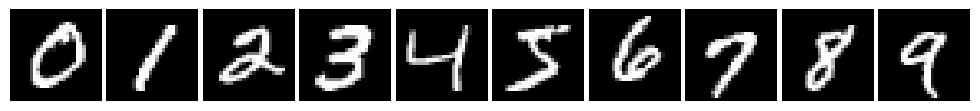

In [4]:
fig, axes = plt.subplots(1, 10, figsize=(10, 1.4))
for i, ax in enumerate(axes):
    idx = int(np.where(train_y == i)[0][0])
    ax.imshow(train_x[idx], cmap="gray", vmin=0, vmax=255)
    ax.set_axis_off()
plt.subplots_adjust(left=0.02, right=0.98, bottom=0.02, top=0.98, wspace=0.05)
plt.show()